# 멀티모달 RAG
- 동영상 검색 실습

## 0.환경 설정

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
base_path = "/content/drive/MyDrive"

In [3]:
%pip install --upgrade openai pandas tqdm pinecone langchain langchain-openai langchain-pinecone langchain-text-splitters pillow

  Using cached pinecone-9.1.0-cp310-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.2 kB)
  Using cached msgspec-0.21.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (5.8 kB)


- 라이브러리 불러오기

In [4]:
import os
import uuid
import pandas as pd
from tqdm import tqdm
from openai import OpenAI
from pinecone import Pinecone, ServerlessSpec
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnableMap
from langchain_openai import OpenAIEmbeddings
from langchain_openai import ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_pinecone import PineconeVectorStore
from PIL import Image
import base64
from IPython.display import display, HTML
from google.colab import userdata

- Key 설정

In [5]:
OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

OPENAI_LLM_MODEL = userdata.get("OPENAI_LLM_MODEL")
OPENAI_EMBEDDING_MODEL = userdata.get("OPENAI_EMBEDDING_MODEL")


PINECONE_API_KEY = userdata.get("PINECONE_API_KEY")
os.environ["PINECONE_API_KEY"] = PINECONE_API_KEY
PINECONE_INDEX_REGION = userdata.get("PINECONE_INDEX_REGION")
PINECONE_INDEX_CLOUD = userdata.get("PINECONE_INDEX_CLOUD")
PINECONE_INDEX_NAME = userdata.get("PINECONE_INDEX_NAME")
PINECONE_INDEX_METRIC = userdata.get("PINECONE_INDEX_METRIC")
PINECONE_INDEX_DIMENSION = int(userdata.get("PINECONE_INDEX_DIMENSION"))

## 1.데이터 전처리
- 데이터 수집 -> 데이터 병합



- 1.데이터 수집

In [6]:
comments_dir = "comments"
comments_dir_path = os.path.join(base_path, comments_dir)

csv_files = [
    os.path.join(comments_dir_path, fname)
    for fname in os.listdir(comments_dir_path)
    if fname.endswith("_frames_success.csv")
]

print(csv_files)  # 파일 경로가 잘 나오면 OK

['/content/drive/MyDrive/comments/swimming_frames_success.csv', '/content/drive/MyDrive/comments/soccer_player_head_frames_success.csv', '/content/drive/MyDrive/comments/skiing_frames_success.csv', '/content/drive/MyDrive/comments/alpinist_frames_success.csv', '/content/drive/MyDrive/comments/surfer_frames_success.csv', '/content/drive/MyDrive/comments/soccer_pass_frames_success.csv', '/content/drive/MyDrive/comments/female_player_after_scoring_frames_success.csv', '/content/drive/MyDrive/comments/basketball_frames_success.csv', '/content/drive/MyDrive/comments/jogging_frames_success.csv']


- 2.데이터 병합

In [7]:
dfs = []

for f in csv_files:
    try:
        df = pd.read_csv(f)
        print(f"{os.path.basename(f)} shape: {df.shape}")

        if not df.empty:
            dfs.append(df)
    except Exception as e:
        # 파일 읽기 중 에러 발생 시 파일명과 에러 메시지 출력
        print(f"Error reading {f}: {e}")

if dfs:
    df_all = pd.concat(dfs, ignore_index=True)
    print(df_all.shape)
    display(df_all)
else:
    print("⚠️ 읽을 데이터가 없습니다.")           # 파일이 없거나 비어있을 경우


swimming_frames_success.csv shape: (9, 4)
soccer_player_head_frames_success.csv shape: (7, 4)
skiing_frames_success.csv shape: (2, 4)
alpinist_frames_success.csv shape: (7, 4)
surfer_frames_success.csv shape: (7, 4)
soccer_pass_frames_success.csv shape: (5, 4)
female_player_after_scoring_frames_success.csv shape: (7, 4)
basketball_frames_success.csv shape: (6, 4)
jogging_frames_success.csv shape: (6, 4)
(56, 4)


,id,video_filename,frame_no,description
0,aa0a7d38-e82b-4b86-af76-2c1bbdbbe081,swimming.mp4,0,The image captures a moment in a swimming pool...
1,d0f396cc-40b1-44cb-af2e-22e4cccab28a,swimming.mp4,30,The image captures a swimmer in motion within ...
2,b108dd85-480b-42e7-8cb2-aa1d6f5e2f66,swimming.mp4,60,"The image captures a swimmer in motion, perfor..."
3,d4d383fc-d56c-4c81-b99a-766f5c09dcc6,swimming.mp4,90,The image captures a swimmer in the middle of ...
4,fe6dea03-b51f-4f39-b6fc-b11c69b46a62,swimming.mp4,120,"The image captures a swimmer in motion, perfor..."
5,43cc1a02-42b5-433d-8d62-e7edd78be348,swimming.mp4,150,The image captures a moment in a swimming pool...
6,c2a1500b-ba11-4b53-a65b-806baefa5724,swimming.mp4,180,The image is a frame from a video showing a sw...
7,af13c1ba-c6f1-418b-8d51-c57c526c2b2d,swimming.mp4,210,The image depicts an indoor swimming pool sett...
8,92bb73d6-3710-4d98-bb70-bb4c5cfa2cb1,swimming.mp4,240,The image depicts a swimmer poised on a starti...
9,918f1db5-ab9b-43c0-aea9-613b70bc43a2,soccer_player_head.mp4,0,The image captures a moment on a soccer field....


## 2.텍스트 청킹(Chunking)
- `df_all`에 통합된 모든 댓글 데이터를 벡터 임베딩하기 전에 **LangChain의 RecursiveCharacterTextSplitter** 를 사용해 텍스트를 일정 길이로 나누는 단계
- 벡터 저장소 구축의 핵심 전처리 구간

In [8]:
# description 컬럼 청킹(512자 기준, Langchain TextSplitter 활용)
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 512,
    chunk_overlap=50
)

chunks = []

for idx, row in tqdm(df_all.iterrows(), total=len(df_all), desc="청킹 중"):
    for chunk in text_splitter.split_text(str(row["description"])):
        chunks.append({
            "id": str(uuid.uuid4()),
            "comment": chunk,
            "frame_no": row["frame_no"],
            "video_filename": row["video_filename"]
        })
df_chunks = pd.DataFrame(chunks)
df_chunks

청킹 중: 100%|██████████| 56/56 [00:00<00:00, 739.38it/s]


,id,comment,frame_no,video_filename
0,11fdaa9b-79cc-43c2-b900-a1a97b690d84,The image captures a moment in a swimming pool...,0,swimming.mp4
1,7e1f0f07-d0e3-4e39-a246-bc0e2e203917,"letter ""A"" is overlaid on the image, positione...",0,swimming.mp4
2,5a2e1da6-ab54-419b-a1af-084feaf13f64,The image captures a swimmer in motion within ...,30,swimming.mp4
3,9402b3eb-be0c-4609-924a-2271aae5ac9b,"The image captures a swimmer in motion, perfor...",60,swimming.mp4
4,94e1fc2a-b8f3-4ef0-b947-196139149836,"ripples and splashes, indicating the swimmer's...",60,swimming.mp4
...,...,...,...,...
73,ab5a6f9d-0c1a-4783-baaa-2c54503a403e,"The image depicts a scene set in a lush, green...",30,jogging.mp4
74,da14bd79-77b9-453b-bd45-3c29e8e3dd4a,"The image is a blurred frame from a video, sho...",60,jogging.mp4
75,824fade0-c3d8-4bae-a44f-4688bb900092,The frame captures a scene of a man running th...,90,jogging.mp4
76,8c3e4f76-ae68-484e-b268-5efb4419edba,This frame from a video shows a blurred image ...,120,jogging.mp4


## 3.벡터 저장소(Vector Store) 생성
- 벡터를 저장할 인덱스 생성 및 연결

In [9]:
# Pinecone 인덱스 생성
pc = Pinecone()

In [10]:
if PINECONE_INDEX_NAME not in [i.name for i in pc.list_indexes()]:
    pc.create_index(
        name=PINECONE_INDEX_NAME,
        dimension=PINECONE_INDEX_DIMENSION,
        metric=PINECONE_INDEX_METRIC,
        spec=ServerlessSpec(
            cloud=PINECONE_INDEX_CLOUD,
            region=PINECONE_INDEX_REGION
        )
    )
index = pc.Index(PINECONE_INDEX_NAME)
index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {'': {'vector_count': 156}},
 'total_vector_count': 156,
 'vector_type': 'dense'}

## 4.임베딩(Embedding)

In [11]:
# 1. 임베딩 모델 인스턴스
embeddings_model = OpenAIEmbeddings(
    model = OPENAI_EMBEDDING_MODEL
)

# 2. Pinecone vectorDB 생성(이미 인덱스 생성되어 있어야 함)
vectorstore = PineconeVectorStore(
    index=index,
    embedding=embeddings_model
)

# 3. 업서트 준비(id 및 metadata 포함)
# 동일 id 존재 시 덮어쓰기
texts = df_chunks['comment'].tolist()
metadatas = [
    {
        "id": row["id"],
        "frame_no": row["frame_no"] ,
        "video_filename": row["video_filename"]
    }
    for _, row in df_chunks.iterrows()
]

# 4. 임베딩 자동 생성
batch_size = 100

for i in tqdm(range(0, len(texts), batch_size), desc="Pinecone 업서트 중"):
    batch_texts = texts[i:i+batch_size]
    batch_metadatas = metadatas[i:i+batch_size]
    vectorstore.add_texts(
        texts=batch_texts,
        metadatas=batch_metadatas
    )

print(f"\n\nPinecone 인덱스({PINECONE_INDEX_NAME})에 총 {len(texts)}개 벡터 업서트 완료.")

Pinecone 업서트 중: 100%|██████████| 1/1 [00:03<00:00,  3.73s/it]



Pinecone 인덱스(sk-new-index)에 총 78개 벡터 업서트 완료.


## 5.데이터 확인

In [12]:
# 쿼리할 텍스트 준비
query = "A video of a female soccer player celebrating a goal?"

# Top-K 유사 문서 검색
top_k = 5
results = vectorstore.similarity_search_with_score(query, k=top_k)

In [13]:
# 검색 결과 문서의 메타데이터를 활용해서 해당 비디오 프레임 이미지를 찾아 썸네일 형태로 출력하는 함수
def show_frame_image_from_metadata(doc, frames_dir="frames", base_path='.', thumb_size=(240, 135)):
    meta = doc.metadata
    video_filename = meta["video_filename"]
    frame_no = int(meta["frame_no"])
    video_basename = os.path.splitext(video_filename)[0]
    image_filename = f"{video_basename}_frame{frame_no:05d}.jpg"
    image_path = os.path.join(base_path, frames_dir, video_basename, image_filename)
    if not os.path.exists(image_path):
        print(f"파일이 없습니다: {image_path}")
        return
    image = Image.open(image_path)
    image.thumbnail(thumb_size)  # 종횡비 유지, thumb_size 이내로 축소
    display(image)


--- Result 1 ---
텍스트: In this frame, two individuals are on a sports field, likely a soccer field, given the netting in the background. The person in the foreground is wearing a red sports uniform and is holding a ball above their head, appearing to be in a celebratory or triumphant pose. Their mouth is open, possibly shouting or cheering. Behind them, another person in a similar red uniform is also visible, seemingly celebrating. The scene conveys a sense of excitement and energy, possibly after a successful play or goal. The
메타데이터: {'frame_no': 150.0, 'id': 'f07a0617-e39b-4735-a4c2-da916fe61dcf', 'video_filename': 'female_player_after_scoring.mp4'}
유사도 점수: 0.564844


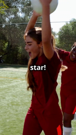


--- Result 2 ---
텍스트: In this frame, two individuals are on a sports field, likely a soccer field, given the netting in the background. The person in the foreground is wearing a red sports uniform and is holding a ball above their head, appearing to be in a celebratory or triumphant pose. Their mouth is open, possibly shouting or cheering. Behind them, another person in a similar red uniform is also visible, seemingly celebrating. The scene conveys a sense of excitement and energy, possibly after a successful play or goal. The
메타데이터: {'frame_no': 150.0, 'id': 'b0377126-fc44-404d-a0aa-83f5e1c233ad', 'video_filename': 'female_player_after_scoring.mp4'}
유사도 점수: 0.564844


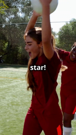


--- Result 3 ---
텍스트: The image captures a dynamic moment on a sports field. A young woman in a red sports jersey is energetically celebrating, holding a white ball under her arm. Her expression is one of excitement and triumph, with her mouth open as if she's shouting or cheering. Behind her, another person in a similar jersey is also celebrating, with arms raised in joy. The background features a net and trees, indicating an outdoor sports setting. The word "Unbelievable" is prominently displayed across the image, emphasizing
메타데이터: {'frame_no': 180.0, 'id': 'ac68aaab-36cb-48ab-8c71-8ae5ca52dbb5', 'video_filename': 'female_player_after_scoring.mp4'}
유사도 점수: 0.551103532


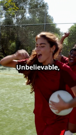


--- Result 4 ---
텍스트: The image captures a dynamic moment on a sports field. A young woman in a red sports jersey is energetically celebrating, holding a white ball under her arm. Her expression is one of excitement and triumph, with her mouth open as if she's shouting or cheering. Behind her, another person in a similar jersey is also celebrating, with arms raised in joy. The background features a net and trees, indicating an outdoor sports setting. The word "Unbelievable" is prominently displayed across the image, emphasizing
메타데이터: {'frame_no': 180.0, 'id': 'ad5f9a66-edba-414d-bfac-53dbc0bf7f13', 'video_filename': 'female_player_after_scoring.mp4'}
유사도 점수: 0.551103532


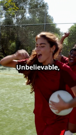


--- Result 5 ---
텍스트: The image captures a moment in a soccer game. A player is performing a header, with the soccer ball just above their forehead. The player is wearing a black shirt and blue shorts, along with blue socks and black cleats. The scene is set outdoors on a grassy field, with a backdrop of lush green hills and a clear blue sky. In the background, there are empty bleachers, indicating a sports field setting. The word "soccer" is overlaid on the image.
메타데이터: {'frame_no': 30.0, 'id': 'd2eafef0-8839-475a-8dd1-9df1f512fda6', 'video_filename': 'soccer_player_head.mp4'}
유사도 점수: 0.523788154


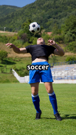

In [14]:
for i, (doc, score) in enumerate(results, 1):
    print(f"--- Result {i} ---")
    print("텍스트:", doc.page_content)
    print("메타데이터:", doc.metadata)
    print("유사도 점수:", score)
    show_frame_image_from_metadata(doc, frames_dir="frames", base_path=base_path, thumb_size=(240,135))
    print()

## 6.RAG 체인 구성

In [15]:
llm = ChatOpenAI(
    model=OPENAI_LLM_MODEL,
    temperature=0
)

In [16]:
prompt = ChatPromptTemplate.from_template("""
당신은 비디오 장면 설명 전문가입니다.
아래는 여러 비디오 프레임의 해설과 정보입니다. 질의에 가장 적합한 프레임을 찾아 답변해 주세요.

질문 : {question}

[참고 프레임 해설들]
{context}

아래 양식에 맞춰 답변해 주세요.
---
1. 답변(질문에 대한 자연스러운 문장)
2. 관련 비디오 파일명
3. 관련 프레임 번호
4. 프레임 해설
""")


def build_context(docs):
    """
    docs: List[Document]  # LangChain 문서 객체
    return: str           # LLM에 넣을 컨텍스트 텍스트
    """
    context = ""
    for i, doc in enumerate(docs, 1):
        m = doc.metadata
        # video_filename, frame_no가 없는 경우 대비해 get() 사용
        context += (
            f"[{i}]\n"
            f"비디오: {m.get('video_filename')}, 프레임: {m.get('frame_no')}\n"
            f"해설: {doc.page_content}\n\n"
        )
    return context


def get_frame_image_path(video_filename, frame_no, frames_dir="frames", base_path="."):
    video_basename = os.path.splitext(video_filename)[0]
    fname = f"{video_basename}_frame{int(frame_no):05d}.jpg"
    return os.path.join(base_path, frames_dir, video_basename, fname)


# 비디오 파일 표시: base64로 인라인 삽입
def display_video_file_base64(video_filename, videos_dir="videos", base_path=".", width=480):
    video_path = os.path.join(base_path, videos_dir, video_filename)
    if not os.path.exists(video_path):
        print(f"비디오 파일이 존재하지 않습니다: {video_path}")
        return
    with open(video_path, "rb") as f:
        video_bytes = f.read()
    video_b64 = base64.b64encode(video_bytes).decode("utf-8")
    video_tag = f"""
    <video width="{width}" controls>
      <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
      Your browser does not support the video tag.
    </video>
    """
    display(HTML(video_tag))

# 프레임 이미지 표시: Base64로 인라인 삽입
def display_frame_image(frame_img_path, width=480):
    if not os.path.exists(frame_img_path):
        print(f"이미지 파일이 존재하지 않습니다: {frame_img_path}")
        return
    with open(frame_img_path, "rb") as f:
        data = base64.b64encode(f.read()).decode("utf-8")
    display(HTML(f'<img src="data:image/jpeg;base64,{data}" width="{width}"/>'))

## 7.검색 및 응답
- 벡터 검색 → 컨텍스트 구성 → LLM 답변 생성 → 프레임 정보 추출

In [17]:
def search_and_answer(vectorstore, llm, query, k=3, base_path="."):
    # 1. 벡터 검색
    docs_and_scores = vectorstore.similarity_search_with_score(query, k=k)
    docs = [d for d, score in docs_and_scores]
    if not docs:
        return {
            "answer": "검색된 관련 프레임이 없습니다.",
            "video_filename": None,
            "frame_no": None,
            "frame_img_path": None
        }

    # 2. 프롬프트 context 구성
    context = build_context(docs)

    # 3. LLM 답변 생성
    messages = prompt.invoke({"context":context, "question":query})
    response = llm.invoke(messages)

    # 4. 답변에서 관련 프레임 정보 추출(최상단 문서, 가장 유사도가 높은)
    meta = docs[0].metadata
    video_filename = meta["video_filename"]
    frame_no = meta["frame_no"]
    frame_img_path = get_frame_image_path(video_filename, frame_no, frames_dir="frames", base_path=base_path)
    return {
        "answer": response.content,
        "video_filename": video_filename,
        "frame_no": frame_no,
        "frame_img_path": frame_img_path
    }

In [18]:
query = "A video of a female soccer player celebrating a goal?"

===== RAG 답변 =====
---
1. 이 비디오에서는 여성 축구 선수가 골을 넣고 기뻐하는 장면을 볼 수 있습니다.
2. female_player_after_scoring.mp4
3. 180.0
4. The image captures a dynamic moment on a sports field. A young woman in a red sports jersey is energetically celebrating, holding a white ball under her arm. Her expression is one of excitement and triumph, with her mouth open as if she's shouting or cheering. Behind her, another person in a similar jersey is also celebrating, with arms raised in joy. The background features a net and trees, indicating an outdoor sports setting. The word "Unbelievable" is prominently displayed across the image, emphasizing

비디오 파일: female_player_after_scoring.mp4
프레임 번호: 150.0

비디오 플레이어:
비디오 파일이 존재하지 않습니다: /content/drive/MyDrive/videos/female_player_after_scoring.mp4
관련 프레임 이미지:



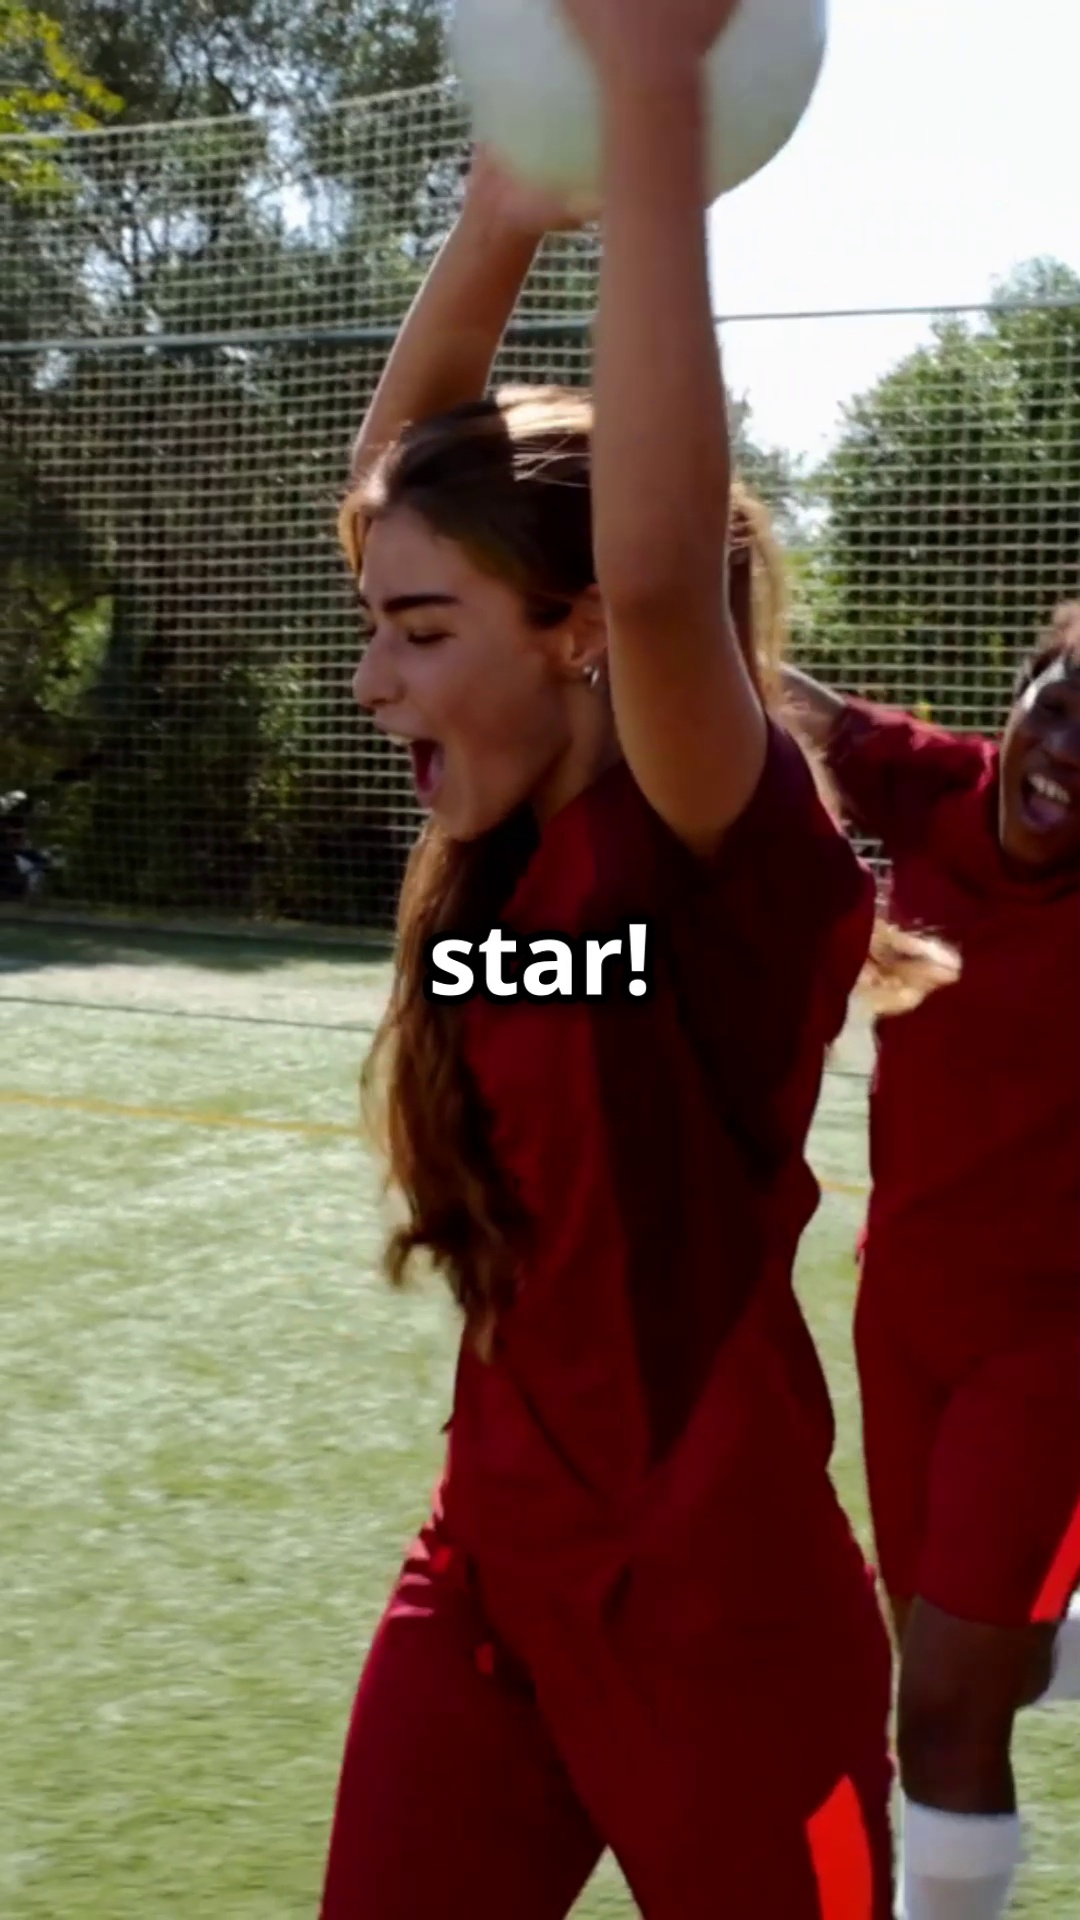

In [19]:
result = search_and_answer(vectorstore, llm, query, k=5, base_path=base_path)

print("===== RAG 답변 =====")
print(result["answer"])
if result["video_filename"] is not None:
    print(f"\n비디오 파일: {result['video_filename']}")
    print(f"프레임 번호: {result['frame_no']}")
    print("\n비디오 플레이어:")
    display_video_file_base64(result['video_filename'], base_path=base_path)
    print("관련 프레임 이미지:")
    display_frame_image(result['frame_img_path'])
else:
    print("추천할 비디오/프레임 정보가 없습니다.")

## [실습]
1. 쿼리를 바꿔가며 검색해보기
2. 검색 결과를 시간으로 변환하기. (예를 들어, 썸네일 이미지가 영상의 몇 초쯤인지)
3. 프롬프트 개선 후 검색 품질 비교하기
4. 중복 검색 결과 제거하기(같은 영상의 비슷한 프레임이 연속으로 여러 개 나오는 문제를 해결)
5. 한국어 검색어와 영어 검색어 비교하기
6. 간단한 동영상 장면 검색 앱 만들기(Streamlit으로 검색어 입력창, 검색 버튼, 결과 표, 썸네일을 표시)

===== RAG 답변 =====
---
1. 골을 넣은 선수는 여성 선수입니다.
2. female_player_after_scoring.mp4
3. 60.0
4. The image captures a soccer ball that appears to be in motion, having just hit the back of a net, suggesting a goal has been scored. The net is prominently visible, with its white mesh contrasting against a dark background. The word "this" is superimposed over the image in white text, positioned centrally. The overall composition emphasizes the dynamic action of the ball and the moment of scoring in a soccer game.

비디오 파일: soccer_player_head.mp4
프레임 번호: 150.0
영상 시간: 5.00초

비디오 플레이어:
비디오 파일이 존재하지 않습니다: /content/drive/MyDrive/videos/soccer_player_head.mp4
관련 프레임 이미지:



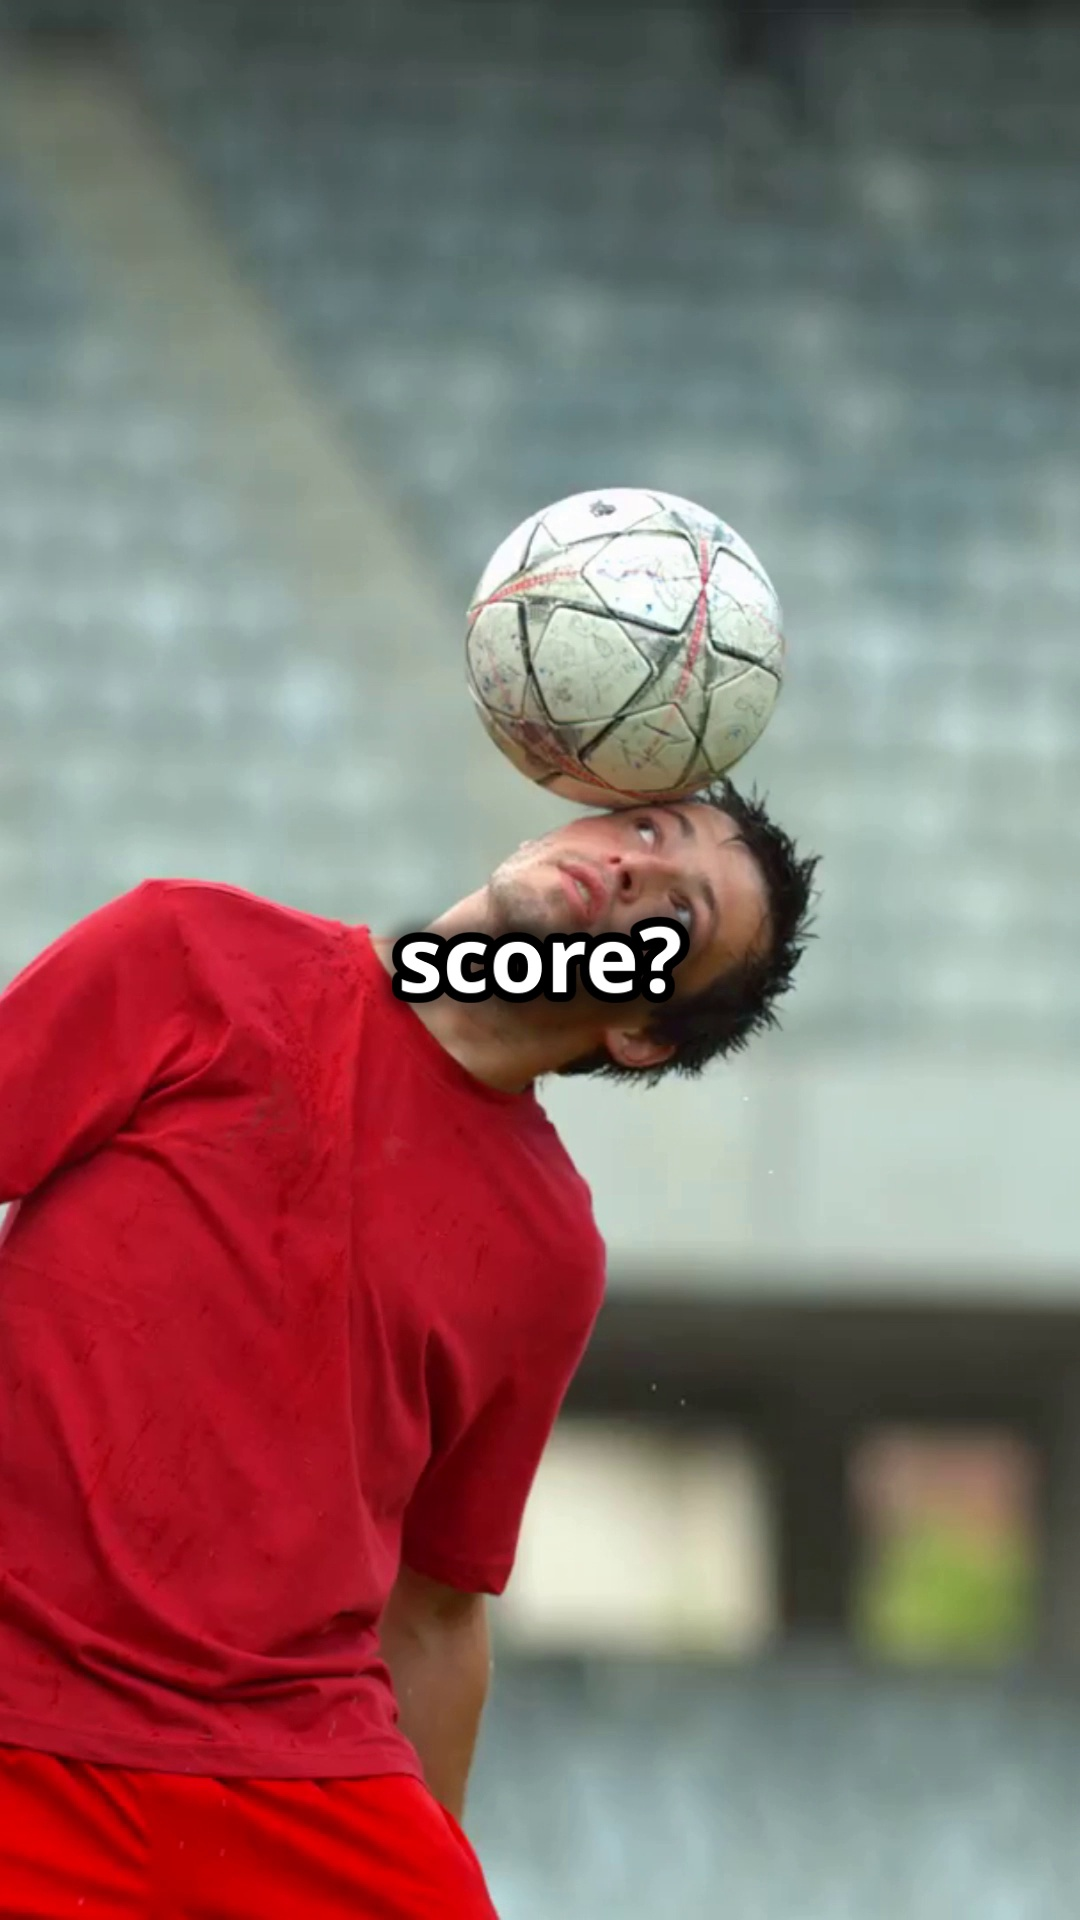

In [21]:
# 쿼리할 텍스트 준비
query = "who did shoot the goal?"
result = search_and_answer(vectorstore, llm, query, k=5, base_path=base_path)

print("===== RAG 답변 =====")
print(result["answer"])
if result["video_filename"] is not None:
    print(f"\n비디오 파일: {result['video_filename']}")
    print(f"프레임 번호: {result['frame_no']}")

    # 프레임 번호를 시간(초)으로 변환
    frames_per_second = 30  # 일반적인 비디오의 FPS를 30으로 가정합니다. 실제 FPS에 맞게 조정하세요.
    if result['frame_no'] is not None:
        time_in_seconds = int(result['frame_no']) / frames_per_second
        print(f"영상 시간: {time_in_seconds:.2f}초")

    print("\n비디오 플레이어:")
    display_video_file_base64(result['video_filename'], base_path=base_path)
    print("관련 프레임 이미지:")
    display_frame_image(result['frame_img_path'])
else:
    print("추천할 비디오/프레임 정보가 없습니다.")